In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import sympy as sm
from scipy.integrate import solve_ivp
#from scipy.fft import fft, fftf

In [2]:
#define the state variables

t = sm.symbols("t")
m, J , λ = sm.symbols("m J λ")
x, y, θ, α, p = [sm.Function(s)(t) for s in ["x", "y", "θ", "α", "p"]]
dx, dy, dθ, dα, dp = [sm.diff(i,t) for i in [x, y, θ, α, p]]
ddx, ddy, ddθ, ddα, ddp = [sm.diff(k,t) for k in [dx, dy, dθ, dα, dp]]
q = sm.Matrix([x, y, θ, α, p])
dq = sm.Matrix([dx, dy, dθ, dα, dp])
ddq = sm.Matrix([ddx, ddy, ddθ, ddα, ddp])

In [3]:
# Trying to find equilibrium points for the MECC system

Iα = 4 * J + m * λ**2 + (m * λ**2 - 4 * J) * sm.cos(α)
eq_dp = -(m * λ**2 * p * dα) / (Iα * sm.tan(α / 2))
eq_dx = (λ / 4) * sm.cos(θ) * sm.tan(α / 2) * ((4 * p * (1 + sm.cos(α)) / Iα) + dα)
eq_dy = (λ / 4) * sm.sin(θ) * sm.tan(α / 2) * ((4 * p * (1 + sm.cos(α)) / Iα) + dα)
eq_dθ = (2 * p * (1 - sm.cos(α)) / Iα) - (dα / 2)
subs = {dx: 0, dy:0, dθ: 0, dα: 0, dp: 0}
sol1 = sm.solve([eq_dx.subs(subs), eq_dy.subs(subs), eq_dθ.subs(subs), eq_dp.subs(subs)],[x, y, θ, α, p],dict = True)
sol1

[{p(t): 0}, {α(t): 0}, {α(t): 2*pi}]

In [4]:
# checking the stability at the equilibrium points α= 0 and pi/2 and p=0
dz = sm.Matrix([eq_dx, eq_dy, eq_dθ, dα, eq_dp])
eq_point = {α: 0}


tan_half_alpha = sm.tan(α/2)
tan_half_series = α/2 + α**3/24
inv_tan_half_series = 2/α - α/6  

eq_dx_smooth = eq_dx.subs({tan_half_alpha: tan_half_series, 1/tan_half_alpha: inv_tan_half_series})
eq_dy_smooth = eq_dy.subs({tan_half_alpha: tan_half_series, 1/tan_half_alpha: inv_tan_half_series})
eq_dθ_smooth = eq_dθ.subs({tan_half_alpha: tan_half_series, 1/tan_half_alpha: inv_tan_half_series})
eq_dp_smooth = eq_dp.subs({tan_half_alpha: tan_half_series, 1/tan_half_alpha: inv_tan_half_series})

rhs_smooth = sm.Matrix([eq_dx_smooth, eq_dy_smooth, eq_dθ_smooth, dα, eq_dp_smooth])
j = rhs_smooth.jacobian(q)
j_eval = j.subs({α: 0, dα: 0})
j2 = rhs_smooth.jacobian(q)
j2_eval = j2.subs({α: -sm.pi, dα: 0})
j2_eval = j2_eval.subs({m: 1, J: 1, λ: 1})
eig2 = j2_eval.eigenvals()
j3 = dz.jacobian(q)
j3_eval = j3.subs({p: 0, dα: 0})
j3_eval = j3_eval.subs({m: 1, J: 1, λ: 1})
eig3 = j3_eval.eigenvals()
#dz.jacobian(q)

small perturbations in the internal angle \alpha only affect the translational velocities \dot{x} and \dot{y}, and not the angular or momentum dynamics. 

Also λ = 0 (with multiplicity 5)

All the interpretation of the equilibrium points are meaningless becase the physical explanaion of the points are for the system without any movements. Now we consider periodic motions in the action space of the system α and try to analyse.  

In [38]:
m, λ, J = 1, 50, 1/12 * 1 * 50**2 
cof = 0.3
α0 = 0.8
WIDTH, HEIGHT = 800, 600


def ode_system(t, state):
    x, y, θ, α, p, x2c, y2c = state
    #α = cof * np.sin(t)+α0
    #α = α if abs(α) > 0.00001 else -α
    dα = cof * np.cos(t)

    Iα = 4 * J + m * λ**2 + (m * λ**2 - 4 * J) * np.cos(α)
    dp = -(m * λ**2 * p * dα) / (Iα * np.tan(α/2))
    dx = (λ / 4) * np.cos(θ) * np.tan(α/2) * ((4 * p * (1 + np.cos(α)) / Iα) + dα)
    dy = (λ / 4) * np.sin(θ) * np.tan(α/2) * ((4 * p * (1 + np.cos(α)) / Iα) + dα)
    dθ = (2 * p * (1 - np.cos(α)) / Iα) - (dα / 2)
    dx2c = dx - λ/2 * np.sin(θ) * dθ - λ/2 * np.sin(θ + α)*(dθ + dα)
    dy2c = dy + λ/2 * np.cos(θ) * dθ + λ/2 * np.cos(θ + α)*(dθ + dα)

    return [dx, dy, dθ, dα, dp, dx2c, dy2c]

# Solve
initial_state = [WIDTH/2, HEIGHT/2, 0, α0, 11160, WIDTH/2+λ/2 * np.cos(0)+λ/2 * np.cos(0+0.8), HEIGHT/2+λ/2 * np.sin(0)+λ/2 * np.sin(0+0.8)]
sol2 = solve_ivp(ode_system, [0,500+0.13], initial_state, t_eval=np.arange(0,500+0.13,0.13), method='RK23',max_step=0.13)
t_vals = sol2.t
x_vals = sol2.y[0]
y_vals = sol2.y[1]
θ_vals = sol2.y[2]
α_vals = sol2.y[3]
p_vals = sol2.y[4]
x2c_vals = sol2.y[5]
y2c_vals = sol2.y[6]

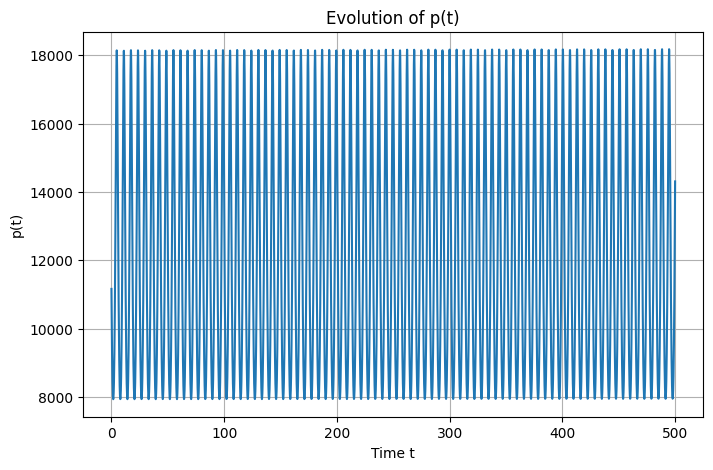

In [39]:
plt.figure(figsize=(8,5))
plt.plot(t_vals, p_vals)
plt.xlabel('Time t')
plt.ylabel('p(t)')
plt.title('Evolution of p(t)')
plt.grid(True)
# plt.xlim([0,800])
# plt.ylim([-2e12,2e12])
plt.show()

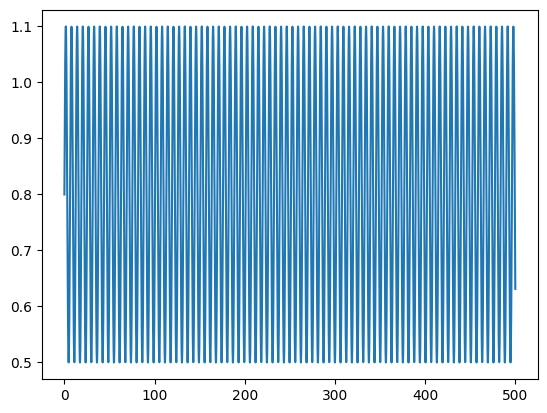

In [40]:
plt.plot(t_vals, α_vals)

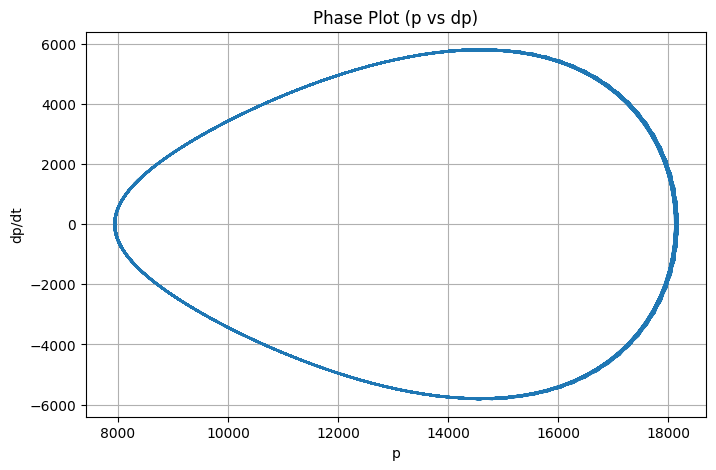

In [41]:
dx_vals, dy_vals, dθ_vals, dα_vals, dp_vals, dx2c_vals, dy2c_vals = [],[],[],[],[],[],[]
for i in range(len(t_vals)):
    state = [x_vals[i], y_vals[i], θ_vals[i], α_vals[i], p_vals[i], x2c_vals[i], y2c_vals[i]]
    dx, dy, dθ, dα, dp, dx2, dy2 = ode_system(t_vals[i], state)

    dx_vals.append(dx)
    dy_vals.append(dy)
    dθ_vals.append(dθ)
    dα_vals.append(dα)
    dp_vals.append(dp)
    dx2c_vals.append(dx2)
    dy2c_vals.append(dy2)

dx_vals = np.array(dx_vals)
dy_vals = np.array(dy_vals)
dθ_vals = np.array(dθ_vals)
dα_vals = np.array(dα_vals)
dp_vals = np.array(dp_vals)
dx2c_vals = np.array(dx2c_vals)
dy2c_vals = np.array(dy2c_vals)

plt.figure(figsize=(8,5))
plt.plot(p_vals, dp_vals)
plt.xlabel('p')
plt.ylabel('dp/dt')
plt.title('Phase Plot (p vs dp)')
plt.grid(True)
plt.show()

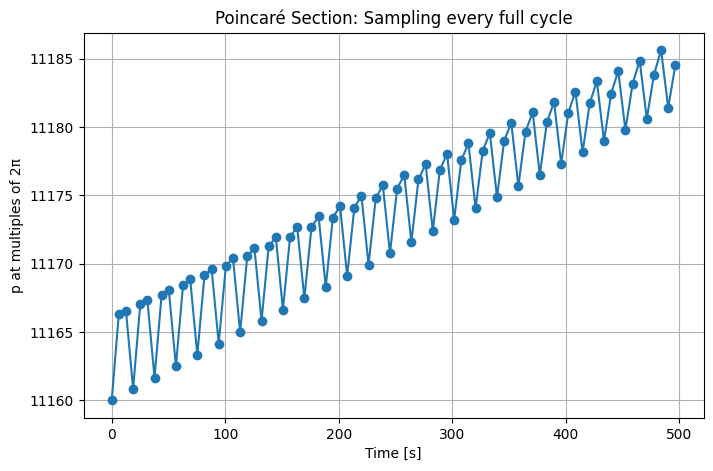

In [42]:
# Define the times at multiples of 2π
T = 2*np.pi
t_poincare = np.arange(0, t_vals[-1], T)

# Interpolate p(t) at these times
from scipy.interpolate import interp1d
p_interp = interp1d(t_vals, p_vals)
p_poincare = p_interp(t_poincare)
plt.figure(figsize=(8,5))
plt.plot(t_poincare, p_poincare, 'o-')
plt.xlabel('Time [s]')
plt.ylabel('p at multiples of 2π')
plt.title('Poincaré Section: Sampling every full cycle')
plt.grid(True)
plt.show()

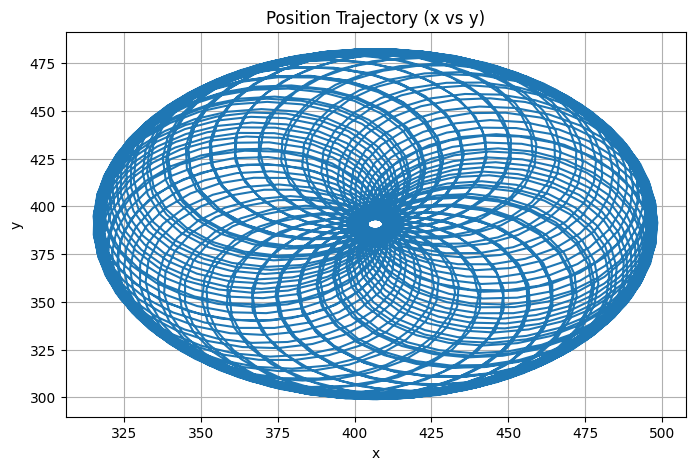

In [43]:

# Plot
plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Position Trajectory (x vs y)')
plt.grid(True)
plt.show()

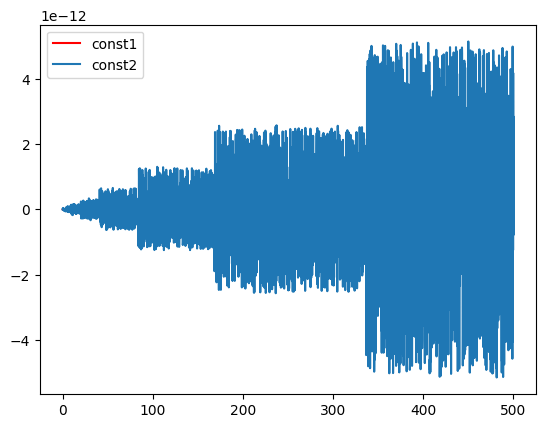

In [44]:
constraint1 = dx_vals*np.sin(θ_vals)-dy_vals*np.cos(θ_vals)
constraint2 = dx2c_vals*np.sin(θ_vals+ α_vals)-dy2c_vals*np.cos(θ_vals+ α_vals)
plt.figure()
plt.plot(t_vals, constraint1, label = 'const1', color = 'r')
plt.plot(t_vals, constraint2, label = 'const2')
plt.legend()
plt.show()